Machine Learning: Algoritmo KNN  

## Intro Teoría KNN

* Usado para predecir un nuevo valor basandose en en función de la distancia entre los datos cercanos (K puntos).
* Cuánto más numero de datos iguales más problable que el resultado sea similar a las caracteristicas de  nuestro valor y --> DUDA
* Calcula da distancia entre puntos cercanos a nuestro dato. Tomamos muestras de K-vecinos distintos, se escoge una métrica de distancia para determinar los K-vecinos.
* Utilizado para problemos supervisados de Clasificación y Regresión aunque es más utilizado en clasificación.

        - Que son problemas supervisados? --> DUDA

        - Definir Clasificacin y Regresión.
* Cómo trabaja el algoritmo KNN?

        1. **Selección del valor de K:** Se elige un valor para K, que representa el número de puntos de datos más cercanos que se considerarán para clasificar o predecir el nuevo punto de datos. Un valor pequeño puede llevar a un modelo más ruidoso y sensible a valores atípicos (outliers), mientras que un valor elevado puede facilitar la toma de decisión.
        2. **Medición de distancia:** Se utiliza una métrica para calcular la distancia entre el punto de datos a clasificar o predecir y los demás puntos de datos en el conjunto de entrenamiento.
        3. **Identificación de los K vecinos más cercanos:** Se seleccionan los K puntos de datos más cercanos (en función de la medición seleccionada).
        4. **Predicción:** Si se trata de un problema de clasificación, el nuevo punto se clasifica en la clase más frecuente entre los K vecinos más cercanos. Si se trata de un problema de regresión, el valor objetivo para el nuevo punto se calcula como la media o la mediana de los valores de los K vecinos más próximos.
* Ejemplos:

        - Clasificar el riesgo crediticio (moroso / no moroso) de una persona basado en infividuos similares.

        - Predecir cuánto dinero gasta un cliente potencial en nuestro negocio en base a los 5 clientes más similares a él y promediar sus gastos para hacer la predicción.





### Métricas de distancia

* Son funcoines utilizadas para medir la proximidad o similitus entre dos puntos de datos en un modelo KNN.

# **EDA**
> * Datos sobre: busca analizar e investigar los conjuntos de datos de los que disponen y resumir sus principales características, visualización de datos para ver su comportamiento y distribución de los mismos.
> * Objetivo: Determinar las mejores variables enfocando el análisis a buscar los vinos de calidad "buena" o "mala".
> * Enfoque: Crear predicciones favorables utilizando Machine Learning KNN. 

## Paso 0: **Imports & Read data**

> (1) **Importar librerías necesarias**  
> - pandas para cargar nuestros datos  
> - matplotlib y seaborn para graficos  
  
> (2) **Crear el DataFrame**  
> (2.1) **Definición del problema e información del conjunto de datos**

### (1) **Importas para EDA:**

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### (2) **Definición de la información del conjunto de datos**

* **Creamos el DataFrame:**

In [43]:
df = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv", sep=";")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


OBSERVACIONES DE .info():    

    - La 1ª columna "#" indica el índex de las variables y la 2ª su nombre/indicador.
    - La 3ª columna cuenta los valores no nulos, dónde sí tenemos data en cada fila y el restante en comparación al total de filas serán las filas que contienen valores nulos. ¿Hay valores NaN? ¿Dónde?
    - La 4ª columna nos dice el tipo de dato que contienen las variables, numéricos o objeto.
    - Por último tenemos un recuento de los tipo de variable y cuánto ocupa en la memoria el total del df. 

In [45]:
df.describe().T.round(2).sort_values("mean", ascending=False)

,count,mean,std,min,25%,50%,75%,max
total sulfur dioxide,1599.0,46.47,32.90,6.00,22.00,38.00,62.00,289.00
free sulfur dioxide,1599.0,15.87,10.46,1.00,7.00,14.00,21.00,72.00
alcohol,1599.0,10.42,1.07,8.40,9.50,10.20,11.10,14.90
fixed acidity,1599.0,8.32,1.74,4.60,7.10,7.90,9.20,15.90
quality,1599.0,5.64,0.81,3.00,5.00,6.00,6.00,8.00
pH,1599.0,3.31,0.15,2.74,3.21,3.31,3.40,4.01
residual sugar,1599.0,2.54,1.41,0.90,1.90,2.20,2.60,15.50
density,1599.0,1.00,0.00,0.99,1.00,1.00,1.00,1.00
sulphates,1599.0,0.66,0.17,0.33,0.55,0.62,0.73,2.00
volatile acidity,1599.0,0.53,0.18,0.12,0.39,0.52,0.64,1.58


### (2) **Descripción de la data inicial:** 

- ¿Qué indican las filas del df?
- Las columnas son los artibutos / características que aporta df de cada fila ¿Qué indican las columnas?

**Observaciones:** COMPLETAR
  * ¿Qué representa una fila? ¿Un cliente, una compra, una medición de sensor…?
  * ¿Qué columnas solo se conocen después del resultado? (posible leakage)
  * ¿Qué queremos predecir o explicar? → **target** (columna objetivo).

**Conclusiones:**

Las variables realmente relevantes:
    
        - col_a,

* Observaciones de la Distribución:  
     - ¿Se observa alta dispersión y presencia de valores extremos?    

* Observaciones de los Valores faltantes:  
     - ¿En qué columnas predominan? ¿Parecen outliers? 


In [46]:
col_numericas = df.select_dtypes(include=['number']).columns.tolist()
col_categoricas = df.select_dtypes(include=['object']).columns.tolist()

print("Columnas numericas:", col_numericas)
print("Columnas categoricas:", col_categoricas)

Columnas numericas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Columnas categoricas: []


COLUMNAS Y CARACTERÍSTICAS DE LAS VARIABLES

**1. NUMÉRICAS:**

> * Medicas:  
    - 
> * Persona:  
    - 

**2. CATEGÓRICAS**  

* **Variable target** 
> ``Outcome``,

* **Variables predictoras:**

* **Variable target:**

In [47]:
df["quality"].unique()

array([5, 6, 7, 4, 8, 3])

* **Filtrado de la columna target por rangos:**
        - Nueva columna 'range_quality' que contiene valor tipo object-string.
        - Los rangos son: 'buena' =  y 'mala'

In [48]:
df["range_quality"] = df["quality"].apply(lambda x: "buena" if x >= 6 else "mala") # Para usar en ML
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,range_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,mala
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,mala
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,mala
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,buena
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,mala


> Vemos que en la columna Quality tenemos un rango de calidades que va del 3 al 8.

Ejemplo:

 "[Link data original]('https:url')"

* **Resumen estadístico del df original:**

* **Resumen estadístico del df ordenado por promedio:**

## Paso **1: Limpieza de datos**

Recuerda: ¿Son todas las características imprescindibles para realizar una predicción? Trataremos de hacer es una eliminación controlada de aquellas variables que estamos seguros de que el algoritmo no va a utilizarlas en el proceso predictivo.

> (1) **Valores NaNs**





### (1) **Valores NaNs**

¿Hay valores NaN? ¿Dónde? ¿Representarían información importante para el análisis?  

In [49]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
range_quality           0
dtype: int64

In [50]:
df_nas = df.loc[df["name"].isna()]

KeyError: 'name'

**Conclusion NaS:**¿Qué hago con ellos? ¿Decido rellenarlos? ¿Eliminar filas o mantenerlas?

### (2) **Valores duplicados**

In [ ]:
df.duplicated().sum()

In [ ]:
df.sample(5, random_state=0)

In [ ]:
df.nunique()

In [ ]:
# initial_rows = df.shape[0]
# df = df.drop_duplicates()
# print(f"✅ Duplicados eliminados: {initial_rows - df.shape[0]} filas borradas.")

### (3) **Valores a 0**

In [ ]:
(df == 0).sum()

In [ ]:
df.loc[(df == 0).any(axis=1)] # Ver filas que contienen almenos un 0

In [ ]:
# df_availability_0 = df.loc[(df["availability_365"]==0)]
# # df_numreviews_0 = df[df['number_of_reviews'] == 0] 
# # df_numreviews_0.count(), df_numreviews_0.count()
# f'El número de apartamentos con 0 disponibilidad es {df_availability_0.shape[0]} y los que no contienen reviews es {df_numreviews_0.shape[0]}.'

**Observaciones de valores a 0:**


> * En las columnas con más valores a 0 son ....Para el análisis podríamos pasarlos a valores NaN sin necesidad de eliminar las columnas pero no/si las utilizaría para el ML ya que representan .... sobre la data en valores nulos.  
>  
> * Decido eliminar las filas que contienen valores zero.... la columna que adquiere/ adquieren mayor importancia son ...

* **Limpieza de filas con valores nulos:**

In [ ]:
df = df.drop(df[(df['BMI'] == 0) & (df['Glucose'] == 0) & (df['BloodPressure'] == 0)].index)

* **Limpieza de columnas con valores nulos:**

In [ ]:
df = df.drop(['SkinThickness', 'Insulin'], axis=1)

* **Características del Nuevo df:**

In [ ]:
df.shape

In [ ]:
df.head(5)

**OBSERVACIONES DESPUES DE LA LIMPIEZA DE DATOS:** Nos quedamos con ... columnas y ... filas.

* **Columnas con mayor importancia:**
> 
 * **Nueva variable target** 
> * ``Si hay nueva``, 

## Paso 2: **Análisis de Variables**

> (1) **Análisis de Variables**  
> (1.1) **Categórica: Variable target**  
> (1.2) **Numéricas** 
> Análisis Multivariante  
> (2) **Correlaciones**     

Columnas numericas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Columnas categoricas: []


## Paso 3: Análisis de variables

> (1) **Descripción de columnas utilizadas para el análisis**   
> (2) **Análisis de Variables Numéricas:**  
> (3) **Análisis de Variables Categóricas,** *tipo de variable que puede tomar uno de un número limitado de categorías o grupo, ninguno de los valores es inherentemente "mayor" o "mejor" que los demás (colores) pero pueden también representarse mediante números finitos (yellow=0, blue=1, pink=2).*

> Tipos de análisis: Univariante & Multivariante  

        - Univariante: Una **variable univariante** es un término estadístico que se emplea para referenciar un conjunto de observaciones de un atributo (obervaciones=características, atributo =columna).  

         - Univariante: 


>   - Según tipo de variable:

1. Numérica - Continua
2. Numérica - Discreta
3. Categórica - Nominal
4. Categórica - 

### (1) **Descripción de columnas utilizadas para el análisis:** 

### (2) **Análisis de Variables Numéricas:**

     -Boxplot: Dentro del rectangulo, dos particiones: cuartil 25% (Q2) y cuartil 50% (Q3)

In [ ]:
df_analisis[df_analisis['number_of_reviews']<60].boxplot(column=['number_of_reviews']) #

In [ ]:
#Calcuo outliers: 
# FORMULA cálculo quantile 3:  Q3 + 1.5*IQR --> 24 + 1.5(24-1) =~ 60

df_analisis.boxplot(column=['number_of_reviews'])
plt.ylim(0,60) # filtro altura de outliers por rango
# plt.ylim(top=60) # corte del gráfico en 60
plt.show()

### (3) **Análisis de Variables Categóricas:**

# **ML**

A los algoritmos de ML le gustan los vectores :)

Para que cada fila sea un vector no debe tener valores nulos y cada celda debe ser un numero y no un texto o fecha u otra cosa que no sea un numero. Entonces deberemos:

1. Eliminar o imputar nulos en el EDA (Paso previo)
2. Eliminar o transformar en numeros las celdas que no son numeros en el EDA. (Paso previo)
3. **Con los algoritmos KNN..... (arboles: no es necesario normalizar la data, además en este proyecto no tenemos ninguna varibale categórica. Sin embargo, en algoritmos como knn, regresion y redes neuronales es bueno aplicar transformaciones de normalizacion a las columnas numericas.)** 

## Paso 0: **Imports ML**
> - split para modelado       
>         from sklearn.model_selection import train_test_split, GridSearchCV
> - sklearn para realizar el ML:  
>    . sklearn.model_selectio para train_test_split  
> . sklearn.preprocessing para StandardScaler, MinMaxScaler  
> . sklearn.preprocessing para LabelEncoder, OneHotEncoder, OrdinalEncoder  
> .sklearn.feature_selection para f_classif, SelectKBest  
>  * ML:  .pickle y .json para guardar los modelos 

In [53]:
# 
import pandas as pd
# Visualizaciones
import matplotlib.pyplot as plt
# Modelado y entrenamiento
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV # sirve para modelos de clasificacion y regresion(cambiamos metricas segun modelo)
from sklearn import tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.dummy import DummyClassifier 
# Guardado de ML
import pickle

In [ ]:
# scaler = StandardScaler()

# # Ajustamos SOLO con el train
# X_train_scaled = scaler.fit_transform(X_train)

# # Transformamos el test
# X_test_scaled = scaler.transform(X_test)

NameError: name 'X_train_scaled' is not defined

In [ ]:
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_val_scaled = scaler.transform(X_val)
# X_test_scaled = scaler.transform(X_test)
# print("X_train_scaled:", X_train_scaled.shape)
# print("X_val_scaled:", X_val_scaled.shape)
# print("X_test_scaled:", X_test_scaled.shape)

## Paso 1: **Lectura de los datos procesados**

In [ ]:
df.to_csv("../data/processed/k-nearest-winequality-red.csv", index=False)
df = pd.read_csv('../data/processed/k-nearest-winequality-red.csv')
pd.DataFrame(df)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,range_quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,mala
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,mala
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,mala
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,buena
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,mala
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,mala
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,buena
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,buena
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,mala


In [ ]:
# df(df['range_quality'=='buena']).count_values()



KeyError: False

**Conclusión:**
> ..... Dado que el valor de glucosa es un gran determinante para en análisis y lo normal sería menos de 100 de glucosa en sangre, filtro la columna copiando el resto de datos procesados para aproximar el resultado a mayores casos de predicción favorables. 

In [ ]:
# df = df[(df['Glucose'] >= 100)].copy() #definir despues del eda si filtro más

## PASO 2: **Split data**


 




Definimos cual es la columna a predecir y que columnas utilizaremos como predictoras.

(Esta separacion deberia hacerse al principio antes de la imputacion de nulos y la transformacion de los datos pero por simplicidad haremos esta pequeña trampa de hacerlo luego.)



In [62]:
df["y"] = df["quality"].apply(lambda x: "buena" if x >= 2 else "mala")
X = df.drop(["y","quality","range_quality"],axis=1)
y = df["y"]

In [63]:
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2


In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


## Paso 3: **Modelado e hiperparametrización** 
> * El árbol de decisión muestra qué variables están siendo utilizadas para separar las clases primero. La variable en la primera división es la que tiene mayor poder de separación entre personas con y sin diabetes en este dataset.
> * Hiperparametrización 
dt_classifier_model = DecisionTreeClassifier(random_state=42, max_depth=3)
dt_classifier_model.fit(X_train, y_train)


In [57]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


**Observaciones:**

> * 


## Paso 4: **Predicción**


### (1) **DataFrame comparativo entre las predicciones y la data de testeo**


* Usamos X_test para predecir
* Análisis Overfitting con x_train vs X_test


In [ ]:
y_pred = knn.predict(X_test)
y_pred
pred_vs_real = pd.DataFrame()
pred_vs_real["y_test"] = y_test
pred_vs_real["predicciones"] = y_pred
pred_vs_real


### (2) **Moda como predictor base**

Aqui utilizaremos los predictores Dummy de sklearn que nos permiten exactamente eso tener una base contra la cual comparar nuestros resultados



predictor_mode = DummyClassifier(strategy='most_frequent')
predictor_mode.fit(X_train, y_train);

predicciones_mode = predictor_mode.predict(X_test)

accuracy_mode = accuracy_score(y_test, predicciones_mode)
print("Accuracy base:", accuracy_mode)


## Paso 5: **Métricas**


### (1) **Métricas del modelo de Clasificación**


* **Accuracy**


from sklearn.metrics import accuracy_score
accuracy= accuracy_score(y_test, y_pred,normalize=False)
print("Accuracy Arbol:", accuracy)



* **Precision score**


print(precision_score(y_test, y_pred,average='micro')) # duda revisar


* **GridScearchCV: Overfitting**


https://4geeks.com/es/lesson/optimizacion-de-hiperparametros-del-modelo 


In [ ]:
# revisa hiperparam. K[]
hyperparams = {"K": [0.001, 0.01, 0.1, 1, 10, 100, 1000],"metrics": ["", None],"weights": [""],"algorithm":[""]}
grid = GridSearchCV(df, hyperparams, scoring = "accuracy", cv = 5)
print(grid)

* **Cassification report**


In [ ]:
print(classification_report(y_test, y_pred)) # DUDA QUE SIGNIFCIAN LOS NUMEROS - INVESTIGAR Y ELEGIR UNA METRICA(ej:ACCURACY)
# probar una a una: precision, recall, ...


### (2) **Matriz de confusión**

Matriz de confusión: Esta matriz muestra cuántos valores se clasificaron correctamente o incorrectamente. Los valores diagonales representan aciertos y los otros representan errores.

Las metricas que obtengamos de este resultado seran las que comuniquemos en nuestro reporte final para decir que tan bien funciona el modelo predictivo que hemos seleccionado


DUDA::: Utilizando la caja negra predictora seleccionada y creando reporte final con el conjunto de prueba (X_test,y_test)


In [ ]:
matrix = confusion_matrix(y_test, y_pred)
print("Accuracy por clase:", matrix.diagonal()/matrix.sum(axis=1))
confussion_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(confussion_matrix, annot=True, fmt='g')
plt.xlabel('Predicho')
plt.ylabel('Real');

**OBSERVACIONES:**

> 


### (2.1) **Matriz de confusión para la predicción en base a la moda**

In [ ]:
matrix_moda = confusion_matrix(y_test, predicciones_mode)
print("Accuracy por clase:", matrix_moda.diagonal()/matrix_moda.sum(axis=1))
confussion_matrix_mode = confusion_matrix(y_test, y_pred)
sns.heatmap(confussion_matrix_mode, annot=True, fmt='g')
plt.xlabel('Predicho')
plt.ylabel('Real');


**OBSERVACIONES DE LAS MATRICES DE CONFUSIÓN:**

>Accuracy / Reporte de clasificación--- DUDA

> Este resultado es bueno o es malo?
> 
> Como saber si mi prediccion es buena o mala?
> 
> - 90% de Accuracy (u otra metrica) es bueno?
> - 30% de Accuracy (u otra metrica) es malo?
> 
> Todo es relativo, cual es el accuracy actual en el negocio? Que se utiliza actualmente para hacer la prediccion? Podemos comparar contra eso? Lo mejoramos o no?
> 
> Lo mas recomendado es establecer una base, si el negocio ya la tiene podemos empezar por alli si no podemos utilizar la media o la moda como predictor base dependiendo si la variable a predecir es numerica o categorica respectivamente.


## Paso 6: **Guardado del modelo**


In [ ]:
with open('../../models/iris-decision-tree-classifier.pkl', 'wb') as file:
    pickle.dump(dt_classifier_model, file)

# CookcookHERNAN?¿ Cargamos los datos

In [ ]:
# Bank marketing
df = pd.read_csv("https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv", sep=";")

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,range_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,mala
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,mala
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,mala
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,buena
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,mala


## Separamos X e y

Definimos cual es la columna a predecir y que columnas utilizaremos como predictoras.

Tambien deberiamos separar aqui en conjunto de entrenamiento y de prueba pero por simplicidad lo haremos despues del EDA.

In [ ]:
X = df.drop("y", axis=1)
y = df["y"]
df["y"] = df[df["range_quality"]]

KeyError: 'range_quality'

## EDA para Maquinas

Aqui preparamos los datos para que los algoritmos de ML puedan funcionar de la mejor manera. Si bien cada algoritmo requiere diferentes transformaciones de los datos de acuerdo a su funcionamiento en este cookbook veremos los pasos mas simples para que todos los algoritmos funcionen. Luego se debera iterar probando distintas tecnicas para obtener un mejor resultado.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Split para modelado
from sklearn.model_selection import train_test_split

# Scaled | Escalado --> sirve aqui?
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Encoding | Codificación --> sirve aqui?
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

# To save models
import json
import pickle

# Feature Selection --> import knn?
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.neighbors import KNeighborsClassifier

### A los algoritmos de ML le gustan los vectores

Para que cada fila sea un vector no debe tener valores nulos y cada celda debe ser un numero y no un texto o fecha u otra cosa que no sea un numero. Entonces deberemos:

1. Eliminar o imputar nulos
2. Eliminar o transformar en numeros las celdas que no son numeros. --> VAR CATEGORICA A NUMERICA
3. En algoritmos como knn, regresion y redes neuronales es bueno aplicar transformaciones de normalizacion a las columnas numericas.

#### Diferenciamos las columnas numericas de las categoricas

In [ ]:
col_numericas = X.select_dtypes(include=['number']).columns.tolist()
col_categoricas = X.select_dtypes(include=['object']).columns.tolist()

print("Columnas numericas:", col_numericas)
print("Columnas categoricas:", col_categoricas)

NameError: name 'X' is not defined

#### Imputamos los nulos de las columnas numericas con la media

In [ ]:
X[col_numericas] = X[col_numericas].fillna(X[col_numericas].mean())

NameError: name 'X' is not defined

#### Transformamos las columnas categoricas a numeros e imputamos los nulos

In [ ]:
X = pd.get_dummies(X, columns=col_categoricas, dtype=int)

NameError: name 'X' is not defined

#### Normalizamos

In [ ]:
from sklearn.preprocessing import StandardScaler
X[col_numericas] = sklearn.preprocessing.StandardScaler().fit_transform(X[col_numericas])

NameError: name 'X' is not defined

## Separamos los conjuntos de train y test

Esta separacion deberia hacerse al principio antes de la imputacion de nulos y la transformacion de los datos pero por simplicidad haremos esta pequeña trampa de hacerlo luego.

PARAMETRO 'random_state'= 

In [ ]:
X_train,X_test,y_train,y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
X_train

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
25611,0.861322,-0.120663,0.517118,0.195414,-0.349494,-0.115781,-0.649003,-0.323542,0.287536,0.398115,...,0,0,0,0,0,0,1,0,1,0
26010,-0.290186,-0.217085,-0.204909,0.195414,1.671136,-0.115781,-0.649003,-0.323542,0.287536,0.398115,...,0,0,0,0,0,0,1,1,0,0
40194,3.644131,3.431535,-0.565922,0.195414,-0.349494,-1.134279,1.104525,0.043776,-1.586283,-2.428157,...,0,0,0,1,0,0,0,0,1,0
297,-0.386145,-0.533350,-0.204909,0.195414,-0.349494,0.648092,0.722722,0.886447,0.712460,0.331680,...,0,0,0,1,0,0,0,0,1,0
36344,1.820911,0.423159,-0.204909,0.195414,-0.349494,-1.898153,-1.058448,-0.064259,-1.360272,-1.257233,...,0,0,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40205,-1.153816,-0.255654,-0.565922,0.195414,-0.349494,-1.134279,1.104525,0.043776,-1.582824,-2.428157,...,0,0,0,0,0,1,0,0,1,0
27316,1.149199,-0.749336,-0.565922,0.195414,1.671136,-0.115781,-0.649003,-0.323542,0.230456,0.398115,...,0,0,1,0,0,0,0,1,0,0
14392,1.341116,-0.490925,0.517118,0.195414,-0.349494,0.839061,0.591424,-0.474791,0.772999,0.845170,...,0,0,0,1,0,0,0,0,1,0
7494,-1.057857,-0.359790,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.716496,0.331680,...,0,0,1,0,0,0,0,0,1,0


In [ ]:
y_train

25611     no
26010     no
40194    yes
297       no
36344     no
        ... 
40205     no
27316     no
14392     no
7494      no
10747     no
Name: y, Length: 32950, dtype: object

In [ ]:
X_test

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
14455,-0.769980,-0.490925,0.878132,0.195414,-0.349494,0.839061,0.591424,-0.474791,0.772422,0.845170,...,0,0,0,0,0,1,0,0,1,0
36380,-0.290186,-0.610488,-0.565922,0.195414,-0.349494,-1.898153,-1.058448,-0.064259,-1.360272,-1.257233,...,0,0,0,0,0,1,0,0,1,0
40076,3.164336,-0.490925,-0.204909,0.195414,-0.349494,-1.134279,1.104525,0.043776,-1.620876,-2.428157,...,0,0,0,0,1,0,0,0,1,0
10778,0.381527,-0.811047,-0.204909,0.195414,-0.349494,0.839061,1.536429,-0.280328,0.772422,0.845170,...,0,0,0,0,0,1,0,0,1,0
27939,-1.153816,-0.440785,-0.204909,0.195414,-0.349494,-1.197935,-1.265761,-2.052098,-1.205177,-0.940281,...,0,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33359,0.765363,1.800069,-0.565922,0.195414,-0.349494,-1.197935,-1.179380,-1.231034,-1.343551,-0.940281,...,0,0,0,0,0,1,0,0,1,0
34998,-0.961898,-0.382932,-0.565922,0.195414,-0.349494,-1.197935,-1.179380,-1.231034,-1.367190,-0.940281,...,0,0,1,0,0,0,0,0,1,0
39861,-0.674021,0.824276,-0.565922,0.195414,1.671136,-1.134279,0.828107,0.151810,-1.672767,-2.428157,...,0,0,0,1,0,0,0,1,0,0
3920,0.381527,1.580227,1.600159,0.195414,-0.349494,0.648092,0.722722,0.886447,0.713036,0.331680,...,0,0,0,1,0,0,0,0,1,0


In [ ]:
y_test

14455     no
36380     no
40076     no
10778     no
27939     no
        ... 
33359    yes
34998     no
39861     no
3920      no
33395     no
Name: y, Length: 8238, dtype: object

## Importar los Algoritmos de ML que vayamos a probar o utilizar

Si la columna a predecir es *CATEGORICA* debemos utilizar un algoritmo de clasificacion:

Ejemplos:
```python
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import HistGradientBoostingClassifier
```

Si la columna a predecir es *NUMERICA* debemos utilizar un algoritmo de regresion.

Ejemplos:
```python
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
```

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

## Probar distintos Algoritmos de ML que queremos utilizar y seleccionar el que consideramos mejor

> Pero como seleccionar el mejor si solo podemos utilizar el conjunto de prueba (X_test) solo al final?

Debemos volver a separar el conjunto de entrenamiento en entrenamiento (X_train) y *validacion* (X_val)

In [ ]:
X_train,X_val,y_train,y_val = sklearn.model_selection.train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

## Entrenamiento de la caja negra

Aqui creamos las cajas negras predictoras utilizando los algoritmos de ML elegidos y los datos de entrenamiento

In [ ]:
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier()
lr = LogisticRegression()
hg = HistGradientBoostingClassifier()

### Entrenamos

In [ ]:
knn.fit(X_train, y_train)
dt.fit(X_train, y_train)
lr.fit(X_train, y_train)
hg.fit(X_train, y_train);

### Probamos los datos en el test de validacion y seleccionamos el mejor

In [ ]:
predicciones_val = knn.predict(X_val)
accuracy = sklearn.metrics.accuracy_score(y_val, predicciones_val)
print("Accuracy total KNN:", accuracy)
matrix = sklearn.metrics.confusion_matrix(y_val, predicciones_val)
print("Accuracy por clase:", matrix.diagonal()/matrix.sum(axis=1))
predicciones_val = dt.predict(X_val)
accuracy = sklearn.metrics.accuracy_score(y_val, predicciones_val)
print("Accuracy Arbol:", accuracy)
matrix = sklearn.metrics.confusion_matrix(y_val, predicciones_val)
print("Accuracy por clase:", matrix.diagonal()/matrix.sum(axis=1))
predicciones_val = lr.predict(X_val)
accuracy = sklearn.metrics.accuracy_score(y_val, predicciones_val)
print("Accuracy Regresion Logistica:", accuracy)
matrix = sklearn.metrics.confusion_matrix(y_val, predicciones_val)
print("Accuracy por clase:", matrix.diagonal()/matrix.sum(axis=1))
predicciones_val = hg.predict(X_val)
accuracy = sklearn.metrics.accuracy_score(y_val, predicciones_val)
print("Accuracy HistGradientBoosting:", accuracy)
matrix = sklearn.metrics.confusion_matrix(y_val, predicciones_val)
print("Accuracy por clase:", matrix.diagonal()/matrix.sum(axis=1))

Accuracy total KNN: 0.8937784522003035
Accuracy por clase: [0.95998632 0.37196765]
Accuracy Arbol: 0.888619119878604
Accuracy por clase: [0.9370725  0.50673854]
Accuracy Regresion Logistica: 0.907587253414264
Accuracy por clase: [0.97093023 0.4083558 ]
Accuracy HistGradientBoosting: 0.9148710166919575
Accuracy por clase: [0.96409029 0.52695418]


## Seleccionando el modelo ganador

Que modelo o caja predictora conviene seleccionar?

Si lo unico que nos interesa es una metrica especifica entoncese seleccionaremos el que mejor resultado tiene en esa metrica.

Hay veces que no solo importa que tan precisa es la prediccion sino que queremos entender que es lo que esta haciendo la caja negra. En el caso de los modelos simples como knn, arboles de desicion o regresion lineal entendemos perfectamente lo que hace el modelo, no es una caja negra. En cambio los modelos de ensemble y boosting son realmente una caja negra por su gran complejidad.

Otras veces podemos priorizar la velocidad de entrenamiento y de prediccion o el tamaño en disco de los modelos generados.

Por lo tanto la seleccion del modelo dependera de los objetivos de nuestro sistema y no solo de precision de prediccion.

## Utilizando la caja negra predictora seleccionada y creando reporte final con el conjunto de prueba (X_test,y_test)

Las metricas que obtengamos de este resultado seran las que comuniquemos en nuestro reporte final para decir que tan bien funciona el modelo predictivo que hemos seleccionado

In [ ]:
predicciones = hg.predict(X_test)

## Comprobando que tan buenas son las predicciones

In [ ]:
pred_vs_real = pd.DataFrame()
pred_vs_real["y_test"] = y_test
pred_vs_real["predicciones"] = predicciones
pred_vs_real

,y_test,predicciones
14455,no,no
36380,no,no
40076,no,no
10778,no,no
27939,no,no
...,...,...
33359,yes,yes
34998,no,no
39861,no,yes
3920,no,no


In [ ]:
accuracy = sklearn.metrics.accuracy_score(y_test, predicciones)
print("Accuracy:", accuracy)

Accuracy: 0.9209759650400583


In [ ]:
matrix = sklearn.metrics.confusion_matrix(y_test, predicciones)
print("Accuracy por clase:", matrix.diagonal()/matrix.sum(axis=1))

Accuracy por clase: [0.96880985 0.54418103]


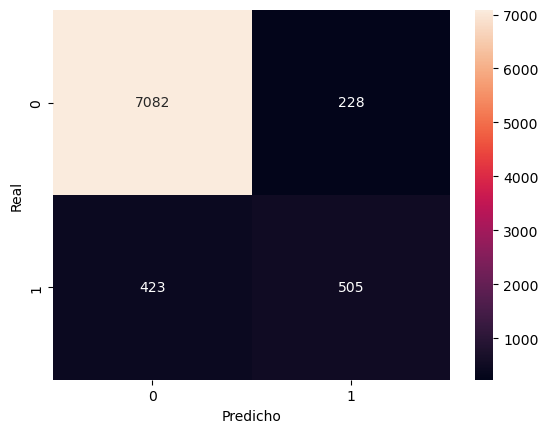

In [ ]:
confussion_matrix = sklearn.metrics.confusion_matrix(y_test, predicciones)
sns.heatmap(confussion_matrix, annot=True, fmt='g')
plt.xlabel('Predicho')
plt.ylabel('Real');

In [ ]:
report = sklearn.metrics.classification_report(y_test, predicciones)
print(report)

              precision    recall  f1-score   support

          no       0.94      0.97      0.96      7310
         yes       0.69      0.54      0.61       928

    accuracy                           0.92      8238
   macro avg       0.82      0.76      0.78      8238
weighted avg       0.91      0.92      0.92      8238



# Conclusiones: Este resultado es bueno o es malo?

Como saber si mi prediccion es buena o mala?

- 90% de Accuracy (u otra metrica) es bueno?
- 30% de Accuracy (u otra metrica) es malo?

Todo es relativo, cual es el accuracy actual en el negocio? Que se utiliza actualmente para hacer la prediccion? Podemos comparar contra eso? Lo mejoramos o no?

Lo mas recomendado es establecer una base, si el negocio ya la tiene podemos empezar por alli si no podemos utilizar la media o la moda como predictor base dependiendo si la variable a predecir es numerica o categorica respectivamente.

Necesitamos poder comparar la métrica resultante con lo que ya tenemos.

## Ejemplo de la moda como predictor base

Aqui utilizaremos los predictores Dummy de sklearn que nos permiten exactamente eso tener una base contra la cual comparar nuestros resultados

In [ ]:
predictor_base = sklearn.dummy.DummyClassifier(strategy='most_frequent')
predictor_base.fit(X_train, y_train);

In [ ]:
predicciones_base = predictor_base.predict(X_test)

In [ ]:
accuracy_base = sklearn.metrics.accuracy_score(y_test, predicciones_base)
print("Accuracy base:", accuracy_base)

Accuracy base: 0.8873512988589464


In [ ]:
matrix = sklearn.metrics.confusion_matrix(y_test, predicciones_base)
print("Accuracy por clase:", matrix.diagonal()/matrix.sum(axis=1))

Accuracy por clase: [1. 0.]


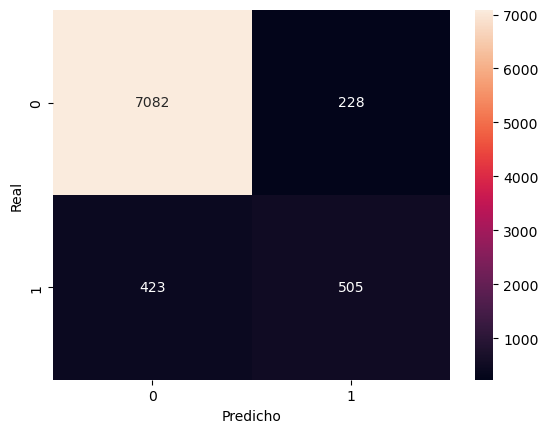

In [ ]:
confussion_matrix = sklearn.metrics.confusion_matrix(y_test, predicciones)
sns.heatmap(confussion_matrix, annot=True, fmt='g')
plt.xlabel('Predicho')
plt.ylabel('Real');

In [ ]:
report = sklearn.metrics.classification_report(y_test, predicciones_base)
print(report)

              precision    recall  f1-score   support

          no       0.89      1.00      0.94      7310
         yes       0.00      0.00      0.00       928

    accuracy                           0.89      8238
   macro avg       0.44      0.50      0.47      8238
weighted avg       0.79      0.89      0.83      8238



c:\Users\CRIS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\CRIS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\CRIS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
